# 01 - Preparación de Datos

Este notebook cubre las fases CRISP-DM de entendimiento del negocio, entendimiento de datos y preparación. La regla metodológica central es NO usar información de test ni datos sintéticos para seleccionar, escalar o validar modelos.

In [1]:
from pathlib import Path
import json
import pickle
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().resolve()
if not (ROOT / 'app').exists() and (ROOT.parent / 'app').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from app.f1_pipeline import (
    CATEGORICAL_FEATURES,
    DEFAULT_SELECTED_FEATURES,
    FeatureEngineer,
    LeakageColumnDropper,
    ColumnSelector,
    Winsorizer,
    smotenc_feature_indices,
)

RANDOM_STATE = 42
SMOTE_SAMPLING_STRATEGY = 0.5  # minority/majority; no iguala clases, limita la minoritaria al 50% de la mayoritaria
DATA_PATH = ROOT / 'f1_final_dataset.csv'
OUTPUT_DIR = ROOT / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 80)
print(f'Root: {ROOT}')

Root: /home/creep/workshop/proyecto-mineria


## Fase 1: Entendimiento del Negocio

El objetivo predictivo es estimar si un piloto terminará una carrera (`finished = 1`) usando solo variables disponibles antes o al inicio de la carrera. Por eso `laps` se elimina: se conoce después del evento y produciría leakage directo.

Criterio de éxito: comparar al menos 4 modelos supervisados y 3 ensambles, seleccionar con validación cruzada sobre el 70% original, aplicar ANOVA/Tukey, optimizar los 3 mejores y desplegar un pipeline que acepte datos crudos pre-carrera.

## Fase 2: Entendimiento de los Datos

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Dataset original: {df.shape[0]:,} filas x {df.shape[1]} columnas')
display(df.head())

target_counts = df['finished'].value_counts().sort_index()
target_pct = df['finished'].value_counts(normalize=True).sort_index().mul(100)
display(pd.DataFrame({'conteo': target_counts, 'porcentaje': target_pct.round(2)}))

Dataset original: 23,777 filas x 30 columnas


,grid,laps,driver_age,driver_race_count,driver_prev_finish_rate,driver_last5_finish_rate,constructor_race_count,constructor_prev_finish_rate,constructor_prev_avg_grid,constructor_last5_finish_rate,circuit_finish_rate,circuit_avg_grid,race_month,race_day_of_year,season_progress,q1_seconds,q2_seconds,q3_seconds,best_q_time,grid_normalized,has_qualifying,front_row_start,top10_start,year,round,driver_nationality_encoded,constructor_nationality_encoded,circuit_country_encoded,circuitRef_encoded,finished
0,16,13,30.929500,85,0.285714,0.0,1,0.0,0.000000,0.0,0.315900,11.747908,8,217,0.666667,87.609,89.824,88.7805,87.264,0.80,0,0,0,1968,8,29,5,10,45,0
1,5,92,32.301164,37,0.361111,0.0,2,0.0,16.000000,0.0,0.165631,11.685300,10,280,0.916667,87.609,89.824,88.7805,87.264,0.25,0,0,1,1968,11,29,5,31,66,0
2,7,78,34.713210,61,0.383333,0.0,3,0.0,10.500000,0.0,0.173913,12.175889,3,65,0.090909,87.609,89.824,88.7805,87.264,0.28,0,0,1,1971,1,29,5,24,33,0
3,11,7,31.036277,8,0.000000,0.0,4,0.0,9.333333,0.0,0.173913,12.175889,3,65,0.090909,87.609,89.824,88.7805,87.264,0.44,0,0,0,1971,1,8,5,24,33,0
4,23,5,41.092402,105,0.076923,0.0,5,0.0,9.750000,0.0,0.173913,12.175889,3,65,0.090909,87.609,89.824,88.7805,87.264,0.92,0,0,0,1971,1,36,5,24,33,0


,conteo,porcentaje
finished,,
0,17768,74.73
1,6009,25.27


In [3]:
quality = {
    'finished_binario': bool(df['finished'].isin([0, 1]).all()),
    'grid_en_rango_0_34': bool(df['grid'].between(0, 34).all()),
    'driver_age_en_rango_17_60': bool(df['driver_age'].between(17, 60).all()),
    'sin_nulos': bool(df.isna().sum().sum() == 0),
    'laps_presente_pero_excluida_por_leakage': 'laps' in df.columns,
}
display(pd.Series(quality, name='cumple'))

desc = df.describe().T
desc['missing'] = df.isna().sum()
desc['missing_pct'] = df.isna().mean().mul(100)
display(desc[['count', 'missing', 'missing_pct', 'mean', 'std', 'min', '50%', 'max']].round(3))

finished_binario                           True
grid_en_rango_0_34                         True
driver_age_en_rango_17_60                  True
sin_nulos                                  True
laps_presente_pero_excluida_por_leakage    True
Name: cumple, dtype: bool

,count,missing,missing_pct,mean,std,min,50%,max
grid,23777.0,0,0.0,11.270,7.346,0.000,11.000,34.000
laps,23777.0,0,0.0,45.271,30.525,0.000,52.000,200.000
driver_age,23777.0,0,0.0,30.175,5.098,17.454,29.645,53.262
driver_race_count,23777.0,0,0.0,59.043,59.434,1.000,39.000,326.000
driver_prev_finish_rate,23777.0,0,0.0,0.216,0.217,0.000,0.158,1.000
driver_last5_finish_rate,23777.0,0,0.0,0.250,0.306,0.000,0.200,1.000
constructor_race_count,23777.0,0,0.0,347.535,417.188,1.000,187.000,2140.000
constructor_prev_finish_rate,23777.0,0,0.0,0.221,0.178,0.000,0.206,1.000
constructor_prev_avg_grid,23777.0,0,0.0,10.973,4.102,0.000,10.502,32.000
constructor_last5_finish_rate,23777.0,0,0.0,0.252,0.299,0.000,0.200,1.000


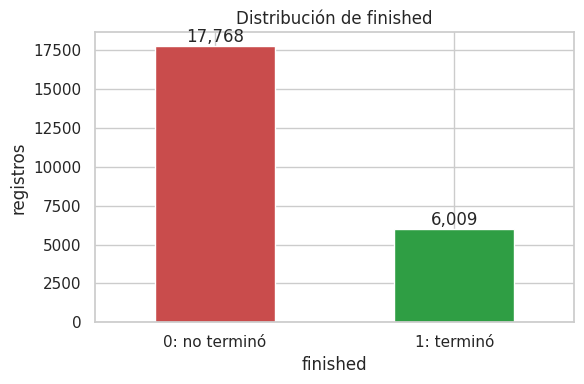

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
target_counts.plot(kind='bar', ax=ax, color=['#c94c4c', '#2f9e44'])
ax.set_title('Distribución de finished')
ax.set_xlabel('finished')
ax.set_ylabel('registros')
ax.set_xticklabels(['0: no terminó', '1: terminó'], rotation=0)
for idx, value in enumerate(target_counts):
    ax.text(idx, value, f'{value:,}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'distribucion_finished.png', dpi=140, bbox_inches='tight')
plt.show()

## Fase 3: Preparación de Datos

La división train/test se hace ANTES de cualquier selección, winsorización, escalado o balanceo. Las decisiones de selección de variables se justifican con diagnósticos calculados solo sobre el 70% de entrenamiento original.

In [5]:
df_model = df.drop(columns=['laps'])
X = df_model.drop(columns=['finished'])
y = df_model['finished']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

print('Split estratificado:')
print(f'Train original: {X_train_raw.shape[0]:,} filas')
print(y_train.value_counts().sort_index().to_dict())
print(f'Test original: {X_test_raw.shape[0]:,} filas')
print(y_test.value_counts().sort_index().to_dict())

Split estratificado:
Train original: 16,643 filas
{0: 12437, 1: 4206}
Test original: 7,134 filas
{0: 5331, 1: 1803}


In [6]:
# Diagnóstico de correlación y MI SOLO con train original.
train_diag = X_train_raw.copy()
train_diag['finished'] = y_train.values
corr_target = train_diag.corr(numeric_only=True)['finished'].drop('finished').abs().sort_values(ascending=False)

fe_diag = FeatureEngineer().fit_transform(X_train_raw)
mi_X = fe_diag.drop(columns=[c for c in fe_diag.columns if c not in DEFAULT_SELECTED_FEATURES], errors='ignore')
mi_scores = mutual_info_classif(mi_X, y_train, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({'feature': mi_X.columns, 'mutual_information': mi_scores}).sort_values('mutual_information', ascending=False)

display(pd.DataFrame({'abs_corr_finished_train': corr_target}).head(20).round(4))
display(mi_df.round(5))

,abs_corr_finished_train
driver_last5_finish_rate,0.4912
constructor_last5_finish_rate,0.4806
driver_prev_finish_rate,0.4692
constructor_prev_finish_rate,0.4559
top10_start,0.3340
grid,0.3289
grid_normalized,0.3245
constructor_race_count,0.2829
constructor_prev_avg_grid,0.2803
driver_race_count,0.2743


,feature,mutual_information
23,avg_finish_rate,0.14011
3,driver_last5_finish_rate,0.12271
0,grid,0.12059
7,constructor_last5_finish_rate,0.11775
2,driver_prev_finish_rate,0.11694
5,constructor_prev_finish_rate,0.10691
6,constructor_prev_avg_grid,0.07164
14,top10_start,0.06220
11,q2_seconds,0.05840
12,q3_seconds,0.05370


In [7]:
selected_features = DEFAULT_SELECTED_FEATURES
removed_features = sorted(set(X_train_raw.columns).union({'experience_ratio', 'grid_above_avg', 'avg_finish_rate'}) - set(selected_features))

print(f'Features seleccionadas ({len(selected_features)}):')
print(selected_features)
print('\nFeatures excluidas por leakage/redundancia/baja utilidad diagnóstica:')
print(removed_features)
print('\nCategóricas para SMOTENC:')
print(CATEGORICAL_FEATURES)

Features seleccionadas (24):
['grid', 'driver_race_count', 'driver_prev_finish_rate', 'driver_last5_finish_rate', 'constructor_race_count', 'constructor_prev_finish_rate', 'constructor_prev_avg_grid', 'constructor_last5_finish_rate', 'circuit_finish_rate', 'circuit_avg_grid', 'q1_seconds', 'q2_seconds', 'q3_seconds', 'has_qualifying', 'top10_start', 'year', 'round', 'driver_nationality_encoded', 'constructor_nationality_encoded', 'circuit_country_encoded', 'circuitRef_encoded', 'experience_ratio', 'grid_above_avg', 'avg_finish_rate']

Features excluidas por leakage/redundancia/baja utilidad diagnóstica:
['best_q_time', 'driver_age', 'front_row_start', 'grid_normalized', 'race_day_of_year', 'race_month', 'season_progress']

Categóricas para SMOTENC:
['has_qualifying', 'top10_start', 'driver_nationality_encoded', 'constructor_nationality_encoded', 'circuit_country_encoded', 'circuitRef_encoded', 'grid_above_avg']


In [8]:
prep_no_sampler = Pipeline([
    ('drop_leakage', LeakageColumnDropper()),
    ('feature_engineering', FeatureEngineer()),
    ('winsorizer', Winsorizer()),
    ('selector', ColumnSelector(selected_features)),
    ('scaler', StandardScaler()),
])

prep_for_smote = Pipeline([
    ('drop_leakage', LeakageColumnDropper()),
    ('feature_engineering', FeatureEngineer()),
    ('winsorizer', Winsorizer()),
    ('selector', ColumnSelector(selected_features)),
])

X_train_selected = prep_for_smote.fit_transform(X_train_raw, y_train)
X_test_selected = prep_for_smote.transform(X_test_raw)

sampler = SMOTENC(
    categorical_features=smotenc_feature_indices(selected_features),
    sampling_strategy=SMOTE_SAMPLING_STRATEGY,
    random_state=RANDOM_STATE,
    k_neighbors=5,
)
X_train_balanced, y_train_balanced = sampler.fit_resample(X_train_selected, y_train)

scaler = StandardScaler()
X_train_balanced_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_balanced), columns=selected_features
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_selected), columns=selected_features
)

train_balanced = X_train_balanced_scaled.copy()
train_balanced['finished'] = y_train_balanced.to_numpy()
test_unbalanced = X_test_scaled.copy()
test_unbalanced['finished'] = y_test.to_numpy()

train_original = X_train_raw.copy()
train_original['finished'] = y_train.to_numpy()
test_original = X_test_raw.copy()
test_original['finished'] = y_test.to_numpy()

train_balanced.to_csv(OUTPUT_DIR / 'train_balanced.csv', index=False)
test_unbalanced.to_csv(OUTPUT_DIR / 'test_unbalanced.csv', index=False)
train_original.to_csv(OUTPUT_DIR / 'train_original.csv', index=False)
test_original.to_csv(OUTPUT_DIR / 'test_unbalanced_raw.csv', index=False)

with open(OUTPUT_DIR / 'preprocessing_pipe.pkl', 'wb') as f:
    pickle.dump(prep_no_sampler, f)

schema = {
    'target': 'finished',
    'leakage_columns_removed': ['laps'],
    'selected_features': selected_features,
    'categorical_features_for_smotenc': CATEGORICAL_FEATURES,
    'smote_sampling_strategy': SMOTE_SAMPLING_STRATEGY,
    'smote_rule': 'La clase minoritaria se sobremuestrea como máximo hasta el 50% de la clase mayoritaria; no se igualan clases.',
    'smotenc_categorical_indices': smotenc_feature_indices(selected_features),
    'cv_rule': 'CV se ejecuta sobre train_original.csv con SMOTENC dentro de cada fold, no sobre train_balanced.csv.',
}
with open(OUTPUT_DIR / 'feature_schema.json', 'w', encoding='utf-8') as f:
    json.dump(schema, f, indent=2, ensure_ascii=False)

print('Artefactos guardados:')
print(f"train_original.csv: {train_original.shape}")
print(f"train_balanced.csv: {train_balanced.shape}; clases {pd.Series(y_train_balanced).value_counts().sort_index().to_dict()}")
print(f"SMOTENC sampling_strategy aplicado: {SMOTE_SAMPLING_STRATEGY}")
print(f"test_unbalanced.csv: {test_unbalanced.shape}; clases {y_test.value_counts().sort_index().to_dict()}")
print('preprocessing_pipe.pkl y feature_schema.json actualizados')

Artefactos guardados:
train_original.csv: (16643, 29)
train_balanced.csv: (18655, 25); clases {0: 12437, 1: 6218}
SMOTENC sampling_strategy aplicado: 0.5
test_unbalanced.csv: (7134, 25); clases {0: 5331, 1: 1803}
preprocessing_pipe.pkl y feature_schema.json actualizados


## Resumen metodológico de preparación

- `laps` se eliminó por ser información posterior a la carrera.
- El split 70/30 se hizo antes de selección, winsorización, escalado y SMOTE.
- `train_balanced.csv` documenta el balanceo exigido sobre el 70%, pero NO se usa para validar modelos.
- `SMOTENC` no iguala clases: la clase minoritaria queda como máximo en el 50% de la clase mayoritaria (`sampling_strategy=0.5`).
- La validación cruzada correcta ocurre en el notebook 02 sobre `train_original.csv`, con `SMOTENC` dentro del pipeline de cada fold.